In [28]:
import pandas as pd
import os
from tqdm import tqdm
import re
import json
import numpy as np
import random
import shutil
from multiprocessing import Pool
import nltk

tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.chunk import ne_chunk
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import string
from concurrent.futures import ProcessPoolExecutor



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/effixis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /home/effixis/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /home/effixis/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 1. Extract risk factors section

### 1.a. Find sections

In [90]:
def extract_risk_factors(text):
    # Normalize the text to handle different cases and line breaks
    normalized_text = text.lower()

    # Define the main regex pattern to extract the content between "Item 1A. Risk Factors" and the subsequent section
    pattern = r'[\r\n]+\s*item[\s\n]*1[\s\n]*a[\s\n]*\.?[\s\n]*-?[\s\n]*risks?\s*factors?[\s\n]*(.*?)(?=[\r\n]+\s*item[\s\n]*1[\s\n]*b[\s\n]*\.?[\s\n]*?-?|[\r\n]+\s*item[\s\n]*2[\s\n]*-?|\Z)'

    # Search for the pattern in the normalized text
    matches = list(re.finditer(pattern, normalized_text, re.DOTALL | re.IGNORECASE))
    
    # Extract the desired section if found
    sections = []
    for match in matches:
        content_start, content_end = match.start(1), match.end(1)
        sections.append(text[content_start:content_end].strip())
    
    # If the main pattern isn't found, check if "Item 1A. Risk Factors" appears standalone
    if not sections:
        standalone_pattern = r'[\r\n]+\s*item[\s\n]*1[\s\n]*a[\s\n]*\.?[\s\n]*-?[\s\n]*risks?\s*factors?[\s\n]*'

        standalone_match = re.search(standalone_pattern, normalized_text)
        if standalone_match:
            sections.append(text[standalone_match.start(1):].strip())

    return sections if sections else None

In [91]:
doc1 = """
 On January 1, 2017, Tiziana Life Sciences plc, a company incorporated in England and Wales Tiziana ), entered into a Shared Services Agreement with us pursuant to which Tiziana agreed to provide certain services to us including various administrative, financial, legal, tax, insurance, facility and information technology services. The term of the agreement is until April 1, 2018 and is renewed automatically thereafter for successive three month terms with respect to any services still in effect unless either party elects not to renew the agreement or any specific service by notice in writing to the other party no later than 45 days prior to the end of any term. We may terminate any of the services provided under the agreement at any time upon 30 days prior written notice. Tiziana may terminate any of the services provided under the agreement if we shall have failed to perform any of our material obligations under the agreement and failed to cure any such failure within 30 days after receiving notice thereof. 
 
 Employees 
 
 As of September 30, 2020 we had no employees. As of September 30, 2019, we had 5 employees. None of our employees were covered by a collective bargaining agreement. We considered our relationship with our employees to be have been good. 

18 

Table of Contents 

ITEM 1 A. RISK FACTORS 

Risks Relating to Our Business 
 
 We are a leukemia-focused biotechnology company with limited operations to date. 
 
 We are a leukemia-focused biotechnology company with limited operations to date and no revenue. We have not yet commenced clinical trials, have no product candidates ready for commercialization, have not generated any revenue from operations and expect to incur substantial net losses for the foreseeable future to further develop and commercialize our product candidates. We are unable to predict the extent of these future net losses, or when we may attain profitability, if at all. We may never be able to generate any revenues or royalties from the sales of our therapeutics or become profitable even if we do generate revenues or royalties. 
19 

our ability to obtain financings to conduct and complete research and development activities including, but not limited to, our human clinical trials, and other business activities; 

 As of September 30, 2020, 173,835 of indebtedness represented by outstanding promissory notes was past due. Although holders have not pursued remedies against us, no assurance can be given that holders will not do so in the future. The institution of collection actions could have a material adverse effect on our business and could force us to seek relief through insolvency or other proceedings. 

43 

Table of Contents 

ITEM 1 B. UNRESOLVED STAFF COMMENTS 

Item 1 B. Unresolved Staff Comments  
"""

doc2 = """

 ITEM 1 - BUSINESS 
 5 
 
 ITEM 1A RISKS FACTORS 
 7 
 
 ITEM 1B UNRESOLVED STAFF COMMENTS 
 12 
 
 ITEM 2 -
"""

doc3 = """

ITEM 1 A. RISK FACTORS 

Risks Relating to Our Business 
 
 We are a leukemia-focused biotechnology company with limited operations to date. 
 


Table of Contents 

ITEM 1 B. UNRESOLVED STAFF COMMENTS 

Item 1 B. Unresolved Staff Comments 

THIS should not be found ITEM 1 A. RISK FACTORS 555555555 Item 1 B. Unresolved Staff Comments 

"""


In [92]:
result = extract_risk_factors(doc3)
if result:
    for r in result:
        print(r)
else:
    print("Section not found!")


Risks Relating to Our Business 
 
 We are a leukemia-focused biotechnology company with limited operations to date. 
 


Table of Contents


In [93]:
for y in range(2006, 2023):
    year = str(y)
    data = {
        "QTR1": {},
        "QTR2": {},
        "QTR3": {},
        "QTR4": {}
    }
    not_found = {
        "QTR1": [],
        "QTR2": [],
        "QTR3": [],
        "QTR4": []
    }
    print(year)
    for qtr in ["QTR1", "QTR2", "QTR3", "QTR4"]:
        path = f"data/10ks/{year}/{qtr}/"
        for filename in tqdm(os.listdir(path)):
        # for filename in ["20210104_10-Q_edgar_data_1098009_0001185185-20-001804.txt"]:
            elts = filename.split("_")
            if elts[1] == "10-K":
                cik = elts[4]
                if cik in data[qtr]:
                    data[qtr][cik]['multiple_reports'] = True
                    data[qtr][cik]['filenames'].append(filename)
                else:
                    data[qtr][cik] = {
                        'filenames': [filename],
                        'multiple_reports': False,
                        'content': []
                    }
                if filename.endswith('.txt'):  # assuming they are all .txt files
                    with open(os.path.join(path, filename), 'r') as file:
                        content = file.read()
                        # Using regular expression to extract the content
                        # .+? ensures non-greedy matching. This means the pattern will try to match as little as possible.
                        sections = extract_risk_factors(content)
                        if sections is None:
                            not_found[qtr].append(filename)
                        else:
                            for section in sections:
                                if len(section) > 3:
                                    data[qtr][cik]['content'].append(section)
    with open(f"{year}_extracted.json", "w") as f:
        json.dump(data, f, indent=4)
    with open(f"{year}_not_found.json", "w") as f:
        json.dump(not_found, f, indent=4)

2006


  9%|▊         | 1084/12615 [00:03<00:34, 335.57it/s]


KeyboardInterrupt: 

### 1.b. Manually adding a few risk factors



For the following years and cik, we haven't extracted the risk factors properly. As they have been breached, we need them for comparisons and will extract the risk factors manually: 
| Year | CIK     |
|------|---------|
| 2008 | 72971   |
| 2009 | 1122304 |
| 2013 | 19617   |
| 2017 | 354190  |
| 2018 | 36104   |
| 2019 | 718332  |
| 2021 | 72971   |
| 2022 | 72971   |

We store the data extracted manually in the "data/intermadiary/manual_extractions" folder and add them to the json files a posteriori.


In [ ]:
for filename in os.listdir("data/intermediary/manual_extractions"):
    with open(os.path.join("data/intermediary/manual_extractions", filename), 'r') as file:
        new_content = file.read()
    year = filename.split("_")[0]
    cik = filename.split("_")[1].split(".")[0]
    with open(f"data/json/{year}_extracted.json", "r") as f:
        data = json.load(f)
    try:
        data["QTR1"][cik]["content"].append(new_content)
    except KeyError:
        data["QTR1"][cik] = {
            "filenames": [
                filename
            ],
            "multiple_reports": False,
            "content": [content]
        }
    with open(f"data/json/{year}_extracted.json", "w") as f:
        json.dump(data, f)  

### 1.c. Risk factor sections as DataFrame

In [ ]:
# Define a function to flatten the JSON structure and get the longest string from "content"
def flatten_json(year, data):
    flat_data = []
    for quarter, quarter_data in data.items():
        for cik, cik_data in quarter_data.items():
            content_data = cik_data.get("content", [])
            if content_data:
                longest_string = max(content_data, key=len)
                flat_data.append({
                    "_year": year,
                    "_cik": cik,
                    "_content": longest_string
                })
    return flat_data

# Iterate over the .json files and convert to dataframe
all_data = []
path = "data/json"
for filename in os.listdir(path):
    if filename.endswith("_extracted.json") and filename.startswith(("2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022")):
        year = filename.split("_")[0]
        with open(os.path.join(path, filename), "r") as file:
            data = json.load(file)
            flat_data = flatten_json(year, data)
            all_data.extend(flat_data)

# Convert list of dictionaries to DataFrame
df = pd.DataFrame(all_data)

# Now group by "year" and "cik" to get the longest string for each year and cik
def get_longest_string(strings):
    return max(strings, key=len)

df = df.groupby(['_year', '_cik'])['_content'].agg(get_longest_string).reset_index()

# Create a "year_cik" index
df['_year_cik'] = df['_year'] + "_" + df['_cik']
df.set_index('_year_cik', inplace=True)

In [ ]:
df.to_csv("data/intermediary/risk_factors.csv")

### 1.d. Validation

We randomly sample 10 files from the overall dataset and 10 files from breached (cik, year) to check how well our extraction worked.

In [ ]:
breaches = pd.read_csv("data/intermediary/breaches_occurences.csv", index = 0)


In [ ]:
def get_all_txt_files(root_folder):
    txt_files = []
    
    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.endswith('.txt') and "_10-K_" in filename:
                full_path = os.path.join(dirpath, filename)
                txt_files.append(full_path)
                
    return txt_files

def get_breached_txt_files(root_folder):
    df_breaches = pd.read_csv("data/intermediary/breaches_occurences.csv")
    txt_files = []
    
    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.endswith('.txt') and "_10-K_" in filename:
                year = filename[:4]
                cik = filename.split("_")[4]
                if f"{year}_{cik}" in df_breaches["year_cik"].values:
                    full_path = os.path.join(dirpath, filename)
                    txt_files.append(full_path)
                
    return txt_files

def sample_txt_files(root_folder, num_samples=10, breaches = False):
    if breaches:
        all_txt_files = get_breached_txt_files(root_folder)
    else:
        all_txt_files = get_all_txt_files(root_folder)
    
    if len(all_txt_files) < num_samples:
        print(f"Warning: Only found {len(all_txt_files)} files but requested {num_samples} samples.")
        return all_txt_files
    
    sampled_files = random.sample(all_txt_files, num_samples)
    all_sampled = []
    for sampled_file in sampled_files:
        year = sampled_file.split("/")[2]
        cik = sampled_file.split("/")[-1].split("_")[4]
        all_sampled = all_sampled + [
            y for y in all_txt_files if y.split("/")[2] == year and y.split("/")[-1].split("_")[4] == cik
        ]
    return all_sampled

def copy_files_to_directory(filepaths, target_directory):
    # Create target directory if it doesn't exist
    if not os.path.exists(target_directory):
        os.makedirs(target_directory)
    
    for filepath in filepaths:
        shutil.copy(filepath, target_directory)

root_folder = 'data/10ks/'  # or the path to your '10k' folder
target_directory_overall = 'data/validation/overall/raw'
sampled_files_overall = sample_txt_files(root_folder)

copy_files_to_directory(sampled_files_overall, target_directory_overall)

print(f"Copied the sampled files to {target_directory_overall}")

target_directory_breaches = 'data/validation/breaches/raw'
sampled_files_breaches = sample_txt_files(root_folder, breaches = True)

copy_files_to_directory(sampled_files_breaches, target_directory_breaches)

print(f"Copied the sampled files to {target_directory_overall}")

In [2]:
df = pd.read_csv("data/intermediary/risk_factors.csv")

In [ ]:
for path in sampled_files_overall:
    filename = path.split("/")[-1]
    cik = filename.split("_")[4]
    year = filename.split("_")[0][:4]
    with open(f"data/validation/overall/extracted/{filename}", "w") as f:
        try:
            f.write(df[df['year_cik'] == f"{year}_{cik}"]['content'].values[0])
        except IndexError:
            f.write("Nothing extracted")

for path in sampled_files_breaches:
    filename = path.split("/")[-1]
    cik = filename.split("_")[4]
    year = filename.split("_")[0][:4]
    with open(f"data/validation/breaches/extracted/{filename}", "w") as f:
        try:
            f.write(df[df['year_cik'] == f"{year}_{cik}"]['content'].values[0])
        except IndexError:
            f.write("Nothing extracted")

#### Results overall

- 'data/10ks/2015/QTR3/20150902_10-K_edgar_data_1425289_0001640334-15-000108.txt' - EXTRACTION OK
- 'data/10ks/2015/QTR1/20150331_10-K_edgar_data_1308085_0001193125-15-113700.txt' - EXTRACTION OK
- 'data/10ks/2008/QTR1/20080331_10-K_edgar_data_1308606_0000950144-08-002449.txt' - EXTRACTION OK
- 'data/10ks/2006/QTR1/20060315_10-K_edgar_data_1068796_0001193125-06-054814.txt' - EXTRACTION OK
- 'data/10ks/2014/QTR1/20140128_10-K_edgar_data_781902_0001471242-14-000042.txt'- NOTHING TO EXTRACT
- 'data/10ks/2012/QTR3/20120917_10-K_edgar_data_1342287_0001193125-12-392761.txt' - EXTRACTION OK
- 'data/10ks/2018/QTR1/20180305_10-K_edgar_data_1129260_0001129260-18-000008.txt' - EXTRACTION OK
- 'data/10ks/2014/QTR1/20140304_10-K_edgar_data_914577_0001104659-14-015620.txt' - EXTRACTION OK
- 'data/10ks/2017/QTR1/20170217_10-K_edgar_data_1137774_0001137774-17-000084.txt' - EXTRACTION OK
- 'data/10ks/2013/QTR3/20130722_10-K_edgar_data_97472_0000097472-13-000023.txt' - EXTRACTION OK

#### Results breaches

- 'data/10ks/2020/QTR3/20200812_10-K_edgar_data_1157408_0001558370-20-010355.txt' - EXTRACTION OK
- 'data/10ks/2019/QTR1/20190221_10-K_edgar_data_49071_0000049071-19-000023.txt' - EXTRACTION OK
- 'data/10ks/2018/QTR1/20180214_10-K_edgar_data_1585689_0001585689-18-000033.txt' - EXTRACTION OK
- 'data/10ks/2016/QTR1/20160310_10-K_edgar_data_1512673_0001512673-16-000002.txt' - EXTRACTION OK
- 'data/10ks/2014/QTR2/20140627_10-K_edgar_data_726958_0001193125-14-253245.txt' - EXTRACTION OK
- 'data/10ks/2011/QTR1/20110210_10-K_edgar_data_844143_0001047469-11-000740.txt' - EXTRACTION OK
- 'data/10ks/2008/QTR1/20080229_10-K_edgar_data_949157_0000949157-08-000008.txt' - EXTRACTION OK
- 'data/10ks/2009/QTR3/20090911_10-K_edgar_data_1084869_0001084869-09-000027.txt' - EXTRACTION OK
- 'data/10ks/2016/QTR1/20160311_10-K_edgar_data_826154_0000826154-16-000115.txt' - EXTRACTION OK
- 'data/10ks/2017/QTR1/20170301_10-K_edgar_data_813762_0000813762-17-000010.txt' - EXTRACTION OK

# 2. Extract cybersecurity sentences

In [29]:
df = pd.read_csv("data/intermediary/risk_factors.csv")

In [30]:
direct_conditions = [
    [
        ['threat'],
        ['cyber-', 'cyber', 'networks', 'systems', 'products', 'services', 'datacenter', 'infrastructure'], 
        ['terror', 'war', 'contraband', 'bombs']
    ],
    [ 
        ['attack'], 
        ['cyber-', 'cyber', 'networks', 'systems', 'products', 'services', 'datacenter', 'infrastructure'],
        ['terror', 'simulator', 'disease', 'legal action', 'competitive', 'competitors', 'substitute', 'patent', 'nuclear', 'life', 'threaten', 'threatened']
    ],
    [
        ['computer', 'information system'], 
        ['malware', 'virus', 'viruses', 'intrusions', 'software', 'programs', 'third parties', 'attacks'], 
        ['fires', 'product sales', 'warranty claim', 'warranty claims', 'fiduciary duty', 'fiduciary duties', 'covenant', 'covenants', 'credit', 'agreement','agreements', 'warranty', 'warranties', 'obligations', 'regulations', 'contracts', 'contracts', 'resolution']
    ],
    [
        
        ['breaches'],
        ['malware', 'virus', 'viruses', 'intrusions', 'software', 'programs', 'third parties', 'attacks'], 
        ['fires', 'product sales', 'warranty claim', 'warranty claims', 'fiduciary duty', 'fiduciary duties', 'covenant', 'covenants', 'credit', 'agreement','agreements', 'warranty', 'warranties', 'obligations', 'regulations', 'contracts', 'contracts', 'resolution']
    ],
    [
        ['malicious'], 
        [], 
        ['fires', 'product sales', 'warranty claim', 'warranty claims', 'fiduciary duty', 'fiduciary duties', 'covenant', 'covenants', 'credit', 'agreement','agreements', 'warranty', 'warranties', 'obligations', 'regulations', 'contracts', 'contracts', 'resolution']
    ],  # No cyber or non-hit keywords for this condition
    [
        ['hacker', 'hacking', 'social engineering', 'denial of service', 'denial-of-service', 'phishing', 'cyberattack', 'cyberattacks', 'cyber risk', 'cyber security', 'cybersecurity', 'cyber intrusions', 'unauthorized access', 'breach in security', 'security breach'], 
        [], 
        []
    ]  # No hit or non-hit keywords for this condition
]

indirect_conditions = [
    (['company', 'regular course'], ['business', 'operation', 'services']),
    (['technology', 'technologies'], ['computer', 'information', 'communication', 'proprietary', 'infrastructure', 'reliance', 'digital', 'advances']),
    (['information'], ['network', 'services', 'systems', 'confidential', 'proprietary', 'account']),
    (['electronic'], ['network', 'services', 'systems', 'information']),
    (['computer', 'telecommunication', 'third-party', 'infrastructure'], ['systems', 'networks', 'facilities']),
    (['collect', 'store', 'transmit', 'retrieve', 'sensitive', 'critical', 'protection'], ['data', 'information']),
    (['it environment', 'it systems', 'operational systems', 'communication systems', 'critical infrastructure'], []),
    (['security'], ['network', 'products', 'services', 'systems', 'devices', 'data', 'infrastructure', 'patches', 'cloud', 'web', 'email', 'vulnerabilities', 'threat', 'breach', 'penetrate', 'bypass', 'compromised', 'incidence', 'incident', 'circumvent', 'measures', 'portfolio', 'solutions', 'practices', 'standards']),
    (['vulnerabilities'], ['network', 'products', 'services', 'systems', 'devices', 'data', 'infrastructure', 'claims']),
    (['integrity', 'reliability', 'protect', 'protection', 'protecting', 'prevent', 'prevention', 'preventing', 'monitors', 'compromise', 'secure', 'failure'], ['network', 'products', 'services', 'systems', 'devices', 'data', 'measures', 'information']),
    (['gain access'], ['network', 'systems', 'data', 'datacenter']),
    (['access', 'accessed', 'modified'], ['improper', 'improperly']),
    (['theft', 'misuse', 'misusing', 'modification', 'destruction', 'lost', 'loss', 'stolen', 'steal', 'disclose', 'publicly disclosed'], ['assets', 'intellectual property', 'data', 'information']),
    (['investigate', 'remediate', 'remediation', 'recover', 'repair', 'replace'], ['network', 'products', 'services', 'systems', 'data', 'measures', 'efforts']),
    (['interruptions', 'disruptions', 'delays'], ['network', 'services', 'system']),
    (['legal'], ['claims', 'actions', 'challenges', 'liability']),
    (['legislative'], ['actions']),
    (['regulatory'], ['actions', 'investigations', 'agencies']),
    (['liability'], ['claims']),
    (['business'], ['adversely', 'material', 'harm disruptive', 'negative']),
    (['operations', 'services'], ['disrupt']),
    (['revenues'], ['reduce', 'adversely', 'loss', 'lose']),
    (['cost'], ['increase', 'increasing', 'remedy']),
    (['operating results', 'operating margin'], ['harm', 'diminish', 'reduce']),
    (['earnings'], ['reduce', 'adversely']),
    (['financial'], ['harm', 'diminish', 'adversely', 'material', 'damage', 'negative']),
    (['competitive position'], ['harm', 'diminish']),
    (['reputation'], ['harm', 'damage', 'loss', 'adverse']),
    (['brand'], ['harm', 'damage'])
]

In [31]:
def is_direct_match(sentence):
    for condition in direct_conditions:
        if any(k in sentence for k in condition[0]):
            if len(condition[1]) == 0 or any(k in sentence for k in condition[1]):
                if len(condition[2]) == 0 or not any(k in sentence for k in condition[2]):
                    return True
    return False
 
def is_indirect_match(sentence):
    for condition in indirect_conditions:
        if any(k in sentence for k in condition[0]):
            if len(condition[1]) == 0 or any(k in sentence for k in condition[1]):
                return True
    return False

def stop_condition(sentence):
    stop_phrases = ["risks relating to", "risks specific to", "risks related to",
                    "risk relating to", "risk specific to", "risk related to"]
    return any(phrase in sentence for phrase in stop_phrases)


In [32]:
def extract_cyber_sentences(text):
    try:
        is_cyber = set()
        
        sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', text.lower())
        sentences_not_lowered = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', text)

        i = 0
        while i < len(sentences):
            sentence = sentences[i]
            if is_direct_match(sentence):
                is_cyber.add(i)
                j = i + 1
                count = 0
                while j < 10 and j < len(sentences):
                    if stop_condition(sentences[j]) and "\n" in sentences[j]:
                        break
                    if is_indirect_match(sentences[j]):
                        is_cyber.add(j)
                    j += 1
            i += 1

        return " ".join([sentences_not_lowered[i] for i in is_cyber])
    except IndexError:
        print

text = """Cybersecurity is becoming increasingly important. The risks specific to the digital realm are high. There was an unrelated event yesterday. Cyber threats are evolving every day. The latest breach was severe. Unrelated to this, the weather is nice today."""

print(extract_cyber_sentences(text))


Cybersecurity is becoming increasingly important. Cyber threats are evolving every day.


In [33]:
sentences = [
    "There may be losses or unauthorized access to or releases of confidential information, including personally identifiable information, that could subject the Company to significant reputational, financial, legal and operational consequences.",
    "The Company’s business requires it to use and store confidential information, including, among other things, personally identifiable information (“PII”) with respect to the Company’s customers and employees.",
    "The Company devotes significant resources to network and data security, including through the use of encryption and other security measures intended to protect its systems and data.",
    "But these measures cannot provide absolute security, and losses or unauthorized access to or releases of confidential information may still occur, which could materially adversely affect the Company’s reputation, financial condition and operating results.",
    "The Company’s business also requires it to share confidential information with suppliers and other third parties.",
    "Although the Company takes steps to secure confidential information that is provided to third parties, such measures may not be effective and losses or unauthorized access to or releases of confidential information may still occur, which could materially adversely affect the Company’s reputation, financial condition and operating results.",
    "For example, the Company may experience a security breach impacting the Company’s information technology systems that compromises the confidentiality, integrity or availability of confidential information.",
    "Such an incident could, among other things, impair the Company’s ability to attract and retain customers for its products and services, impact the Company’s stock price, materially damage supplier relationships, and expose the Company to litigation or government investigations, which could result in penalties, fines or judgments against the Company.",
    "Although malicious attacks perpetrated to gain access to confidential information, including PII, affect many companies across various industries, the Company is at a relatively greater risk of being targeted because of its high profile and the value of the confidential information it creates, owns, manages, stores and processes.",
    "The Company has implemented systems and processes intended to secure its information technology systems and prevent unauthorized access to or loss of sensitive data, including through the use of encryption and authentication technologies.",
    "As with all companies, these security measures may not be sufficient for all eventualities and may be vulnerable to hacking, employee error, malfeasance, system error, faulty password management or other irregularities.",
    "For example, third parties may attempt to fraudulently induce employees or customers into disclosing user names, passwords or other sensitive information, which may in turn be used to access the Company’s information technology systems.",
    "To help protect customers and the Company, the Company monitors its services and systems for unusual activity and may freeze accounts under suspicious circumstances, which, among other things, may result in the delay or loss of customer orders or impede customer access to the Company’s products and services.",
    "In addition to the risks relating to general confidential information described above, the Company may also be subject to specific obligations relating to health data and payment card data.",
    "Health data may be subject to additional privacy, security and breach notification requirements, and the Company may be subject to audit by governmental authorities regarding the Company’s compliance with these obligations.",
    "If the Company fails to adequately comply with these rules and requirements, or if health data is handled in a manner not permitted by law or under the Company’s agreements with healthcare institutions, the Company could be subject to litigation or government investigations, may be liable for associated investigatory expenses, and could also incur significant fees or fines.",
    "Under payment card rules and obligations, if cardholder information is potentially compromised, the Company could be liable for associated investigatory expenses and could also incur significant fees or fines if the Company fails to follow payment card industry data security standards.",
    "The Company could also experience a significant increase in payment card transaction costs or lose the ability to process payment cards if it fails to follow payment card industry data security standards, which would materially adversely affect the Company’s reputation, financial condition and operating results.",
    "While the Company maintains insurance coverage that is intended to address certain aspects of data security risks, such insurance coverage may be insufficient to cover all losses or all types of claims that may arise."
]

In [34]:
df['relevant_content'] = df['_content'].progress_apply(extract_cyber_sentences)


100%|██████████| 114703/114703 [11:08<00:00, 171.54it/s]


In [35]:
(df['relevant_content'] != '').sum()

52431

In [36]:
df.drop(columns = ["_content"]).to_csv("data/intermediary/risk_factors_relevant.csv")

# 3. Count words occurences

In [37]:
df = pd.read_csv("data/intermediary/risk_factors_relevant.csv", dtype = str, index_col = 0)

In [16]:
df

,_year_cik,_year,_cik,_content,relevant_content
0,2006_1000045,2006,1000045,"The following factors, as well as other factor...",NaN
1,2006_1000180,2006,1000180,Our operating results may fluctuate significan...,NaN
2,2006_1000209,2006,1000209,Interest rate fluctuations may adversely affec...,NaN
3,2006_1000227,2006,1000227,Investing in our securities involves risks. Yo...,NaN
4,2006_1000228,2006,1000228,The healthcare products distribution industry ...,NaN
...,...,...,...,...,...
114698,2022_98362,2022,98362,The following are certain risk factors that co...,\n Risks Related to Data Privacy and Informati...
114699,2022_99250,2022,99250,"FORWARD-LOOKING STATEMENTS \n The reports, fil...",In addition to the oversight of our business p...
114700,2022_99302,2022,99302,You should carefully consider the following\nr...,We rely extensively on information technology...
114701,2022_99780,2022,99780,. \n Our business is subject to a number of ri...,Information technology security threats to net...


In [38]:
df_kws = pd.read_excel("data/WordRoots.xlsx")

In [39]:
lemmatizer = WordNetLemmatizer()

# List of English stopwords
stop_words = set(stopwords.words('english'))

# List of pronouns to remove
pronouns = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", 
            "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", 
            "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those"]

stop_words_set = set(stop_words)
pronouns_set = set(pronouns)

def clean_simplified(text, kw = False):
    stop_words_set = set(stopwords.words('english'))
    pronouns_set = {"i", "me", "my", "mine", "we", "us", "our", "ours", "you", "your", "yours", "he", "him", "his", "she", "her", "hers", "it", "its", "they", "them", "their", "theirs"}
    lemmatizer = WordNetLemmatizer()

    # Tokenize the text
    words = word_tokenize(text.replace('\n', ' '))
    
    filtered_words = []
    for word in words:
        lemmatized_word = lemmatizer.lemmatize(word.lower())
        
        # Filter stop words, pronouns, and punctuation
        if (lemmatized_word not in stop_words_set 
            and lemmatized_word not in pronouns_set 
            and lemmatized_word not in string.punctuation):
            filtered_words.append(lemmatized_word)

    return filtered_words

In [40]:
kws = list(df_kws['wordorigin'].values)
kws.remove("cannot")
kws.remove("uses")

clean_kws = [clean_simplified(kw)[0] for kw in kws]
kews_set = set(clean_kws)

In [41]:
cleaned = []

for index, row in tqdm(df.iterrows(), total = df.shape[0]):
    if not isinstance(row['relevant_content'], str):
        cleaned.append(float('nan'))
    else:
        cleaned.append(clean_simplified(row['relevant_content']))

100%|██████████| 114703/114703 [01:10<00:00, 1624.49it/s]


In [42]:
df['relevant_content_cleaned'] = cleaned
df.drop(columns = ["relevant_content"], inplace = True)

In [43]:
df

,_year_cik,_year,_cik,relevant_content_cleaned
0,2006_1000045,2006,1000045,NaN
1,2006_1000180,2006,1000180,NaN
2,2006_1000209,2006,1000209,NaN
3,2006_1000227,2006,1000227,NaN
4,2006_1000228,2006,1000228,NaN
...,...,...,...,...
114698,2022_98362,2022,98362,"[risk, related, data, privacy, information, se..."
114699,2022_99250,2022,99250,"[addition, oversight, business, provided, mana..."
114700,2022_99302,2022,99302,"[rely, extensively, information, technology, s..."
114701,2022_99780,2022,99780,"[information, technology, security, threat, ne..."


In [44]:
def count_kw(clean_kw):
    return df['relevant_content_cleaned'].apply(lambda x: 0 if isinstance(x, float) else x.count(clean_kw))

In [45]:
results = []

for kw in tqdm(clean_kws):
    results.append(count_kw(kw))

100%|██████████| 3208/3208 [05:09<00:00, 10.37it/s]


In [46]:
for result, kw in tqdm(zip(results, kws)):
    df[kw] = result

0it [00:00, ?it/s]/tmp/ipykernel_5011/1678007677.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[kw] = result
/tmp/ipykernel_5011/1678007677.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[kw] = result
/tmp/ipykernel_5011/1678007677.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df

In [47]:
df

,_year_cik,_year,_cik,relevant_content_cleaned,abandon,abet,abide,ability,able,abnormal,...,world,worldwide,worm,write,wrong,wrongdoing,wrongful,yield,young,zone
0,2006_1000045,2006,1000045,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006_1000180,2006,1000180,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2006_1000209,2006,1000209,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2006_1000227,2006,1000227,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006_1000228,2006,1000228,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114698,2022_98362,2022,98362,"[risk, related, data, privacy, information, se...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
114699,2022_99250,2022,99250,"[addition, oversight, business, provided, mana...",0,0,0,5,1,0,...,0,0,0,0,0,0,0,0,0,0
114700,2022_99302,2022,99302,"[rely, extensively, information, technology, s...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
114701,2022_99780,2022,99780,"[information, technology, security, threat, ne...",0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
df['occurences'] = df[kws].apply(list, axis = 1)
df.drop(columns = kws, inplace = True)
df.drop(columns = ["relevant_content_cleaned"], inplace = True)

In [49]:
df.to_csv("data/intermediary/occurences_counts.csv", index = False)

# 3. Compute cyberrisk scores


## 3.1 Computations


In [50]:
df_breaches = pd.read_excel("data/aa_plus_prc_breach_list_cik.xlsx")
df_breaches = df_breaches[~(df_breaches['year_breach'] == 2023)]
df_breaches['id'] = df_breaches.apply(lambda x: "_".join([str(x['year_breach']), str(x['cik'])]), axis = 1)
breaches_ciks = df_breaches['cik'].unique().tolist()
df['breach'] = df['_year_cik'].apply(lambda x: x in df_breaches['id'].values)
# Consider only the rows corresponding to (year, cik) pairs that have a breach
df_comparison = df[df['breach'] == True][['_year_cik', '_year', '_cik','occurences']]

In [51]:
df_comparison

,_year_cik,_year,_cik,occurences
2665,2006_12978,2006,12978,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4995,2006_715779,2006,715779,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5162,2006_732717,2006,732717,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6644,2006_900075,2006,900075,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7129,2006_935703,2006,935703,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
114249,2022_859070,2022,859070,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
114364,2022_884887,2022,884887,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
114588,2022_926326,2022,926326,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
114650,2022_943452,2022,943452,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [52]:
def cos_sim(A, B):
    """
    Compute the cosine similarity between two vectors A and B.
    
    Args:
    - A (numpy array): First vector.
    - B (numpy array): Second vector.
    
    Returns:
    - float: cosine similarity between A and B.
    """
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    if norm_B == 0.0 or norm_A == 0.0:
        return 0
    return dot_product / (norm_A * norm_B)

In [53]:
df_comparison['_year'] = df_comparison['_year'].astype(int)
df['_year'] = df['_year'].astype(int)

In [54]:
df['similarities'] = df.apply(lambda x: 
    np.mean([
        cos_sim(x['occurences'], y)
        for y in df_comparison[df_comparison['_year'] == x['_year']-1]['occurences'].values
    ]),
    axis=1
)

/home/effixis/anaconda3/envs/mlenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/effixis/anaconda3/envs/mlenv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [55]:
df.rename(columns = {'similarities':'crscore'}, inplace = True)

In [56]:
df[['_year_cik','_year','_cik','crscore']].to_csv("data/results/crscores.csv")

## 3.2 Correlations with Florackis et al

In [57]:
# Load dataframes
df = pd.read_csv('data/results/crscores.csv', index_col = 0)
excel_df = pd.read_excel('data/florackis_etal_cs_score_cik.xlsx')
excel_df['cik'] = excel_df['cik'].astype(str)
df['_cik'] = df['_cik'].astype(str)

In [58]:
df.dropna(subset=['crscore'], inplace=True)

In [59]:
excel_df['_year_cik'] = excel_df.apply(lambda x: "_".join([str(x['fyear']), str(x['cik'])]), axis = 1)

In [60]:
df.merge(excel_df, left_on=['_year_cik'], right_on=['_year_cik'], how='inner').to_csv("data/results/correlations.csv")

In [61]:
df_merged = df.merge(excel_df, left_on=['_year_cik'], right_on=['_year_cik'], how='inner')[['crscore_x', 'crscore_y']]

In [62]:
df_merged

,crscore_x,crscore_y
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
...,...,...
37841,0.451312,0.541563
37842,0.000000,0.000000
37843,0.372963,0.604003
37844,0.361729,0.542589


In [63]:
correlation = df_merged['crscore_x'].corr(df_merged['crscore_y'])

print(correlation)

0.7947990621340247


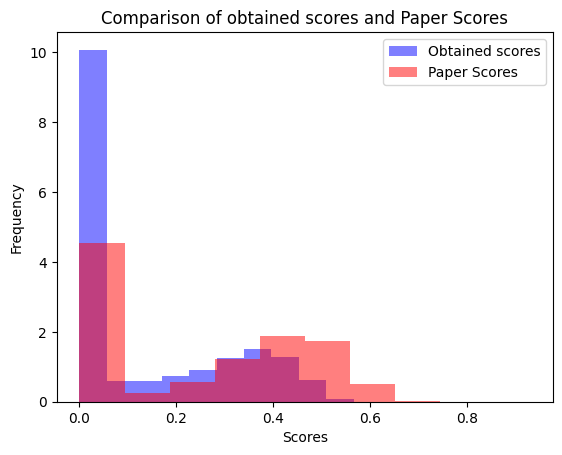

In [64]:
import matplotlib.pyplot as plt

my_scores = df['crscore'].fillna(0)
paper_scores = excel_df['crscore']

# Create histograms
plt.hist(my_scores, bins=10, alpha=0.5, label='Obtained scores', color='blue', density=True)
plt.hist(paper_scores, bins=10, alpha=0.5, label='Paper Scores', color='red', density=True)

# Add legend
plt.legend(loc='upper right')

# Add labels and title
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Comparison of obtained scores and Paper Scores')

# Display the plot
plt.show()
